# Lab 9 – Titanic: Age Distribution by Gender & Survival

**Name:** Gaurav Vishal Doshi &nbsp;&nbsp; **Roll No:** 27

### Aim
- Plot a box plot for distribution of age with respect to each gender along with survival information.
- Write observations from the statistics.

In [1]:
# Cell 1 – Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='Set2')

In [2]:
# Cell 2 – Load Dataset
titanic = sns.load_dataset('titanic')
print('Dataset loaded successfully')
print('Shape:', titanic.shape)
print('Size :', titanic.size)
titanic.head()

Dataset loaded successfully
Shape: (891, 15)
Size : 13365


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Cell 3 – EDA: Info & Describe
print('Info:')
titanic.info()

print('\nDescribe:')
display(titanic.describe())

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Describe:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Cell 4 – Null Counts Before Removal
print('Null counts before removal:')
print(titanic.isnull().sum())

Null counts before removal:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
# Cell 5 – Remove Null Values
titanic_clean = titanic.dropna(
    subset=['survived', 'age', 'fare', 'embarked', 'embark_town']
).reset_index(drop=True)

print('Shape after cleanup:', titanic_clean.shape)
print('\nNull counts after cleanup (key columns):')
print(titanic_clean[['survived', 'age', 'fare']].isnull().sum())

Shape after cleanup: (712, 15)

Null counts after cleanup (key columns):
survived    0
age         0
fare        0
dtype: int64


In [6]:
# Cell 6 – Outlier Removal (IQR on Age & Fare)
titanic_final = titanic_clean.copy()

for col in ['age', 'fare']:
    q1    = titanic_final[col].quantile(0.25)
    q3    = titanic_final[col].quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    titanic_final = titanic_final[
        (titanic_final[col] >= lower) & (titanic_final[col] <= upper)
    ]

titanic_final = titanic_final.reset_index(drop=True)
print('Shape after outlier cleanup:', titanic_final.shape)

Shape after outlier cleanup: (610, 15)


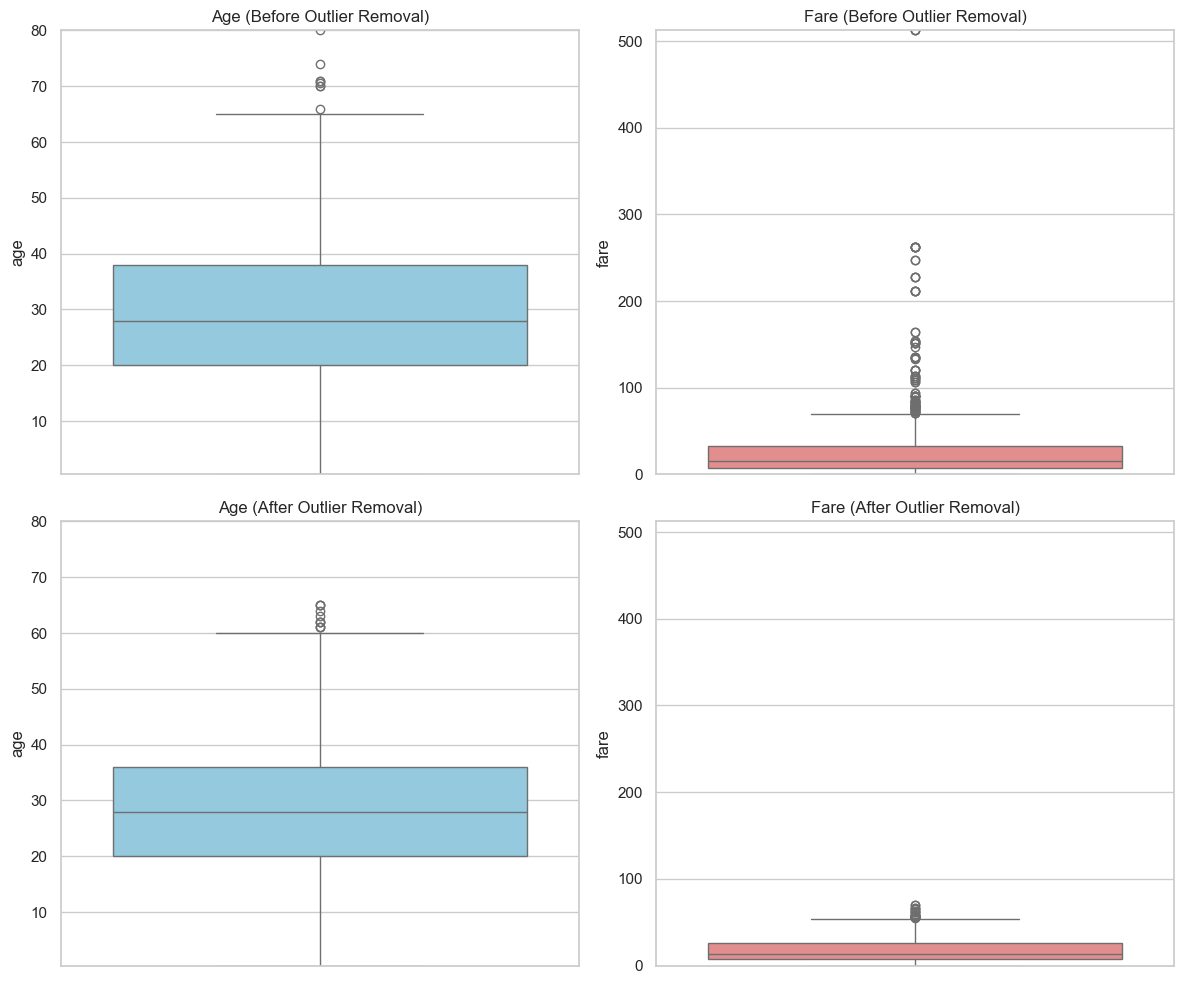

In [7]:
# Cell 7 – Before vs After Outlier Removal (Boxplots)
age_min  = min(titanic_clean['age'].min(),  titanic_final['age'].min())
age_max  = max(titanic_clean['age'].max(),  titanic_final['age'].max())
fare_min = min(titanic_clean['fare'].min(), titanic_final['fare'].min())
fare_max = max(titanic_clean['fare'].max(), titanic_final['fare'].max())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=titanic_clean, y='age',  color='skyblue',    ax=axes[0, 0])
axes[0, 0].set_title('Age (Before Outlier Removal)')
axes[0, 0].set_ylim(age_min, age_max)

sns.boxplot(data=titanic_clean, y='fare', color='lightcoral', ax=axes[0, 1])
axes[0, 1].set_title('Fare (Before Outlier Removal)')
axes[0, 1].set_ylim(fare_min, fare_max)

sns.boxplot(data=titanic_final, y='age',  color='skyblue',    ax=axes[1, 0])
axes[1, 0].set_title('Age (After Outlier Removal)')
axes[1, 0].set_ylim(age_min, age_max)

sns.boxplot(data=titanic_final, y='fare', color='lightcoral', ax=axes[1, 1])
axes[1, 1].set_title('Fare (After Outlier Removal)')
axes[1, 1].set_ylim(fare_min, fare_max)

plt.tight_layout()
plt.show()

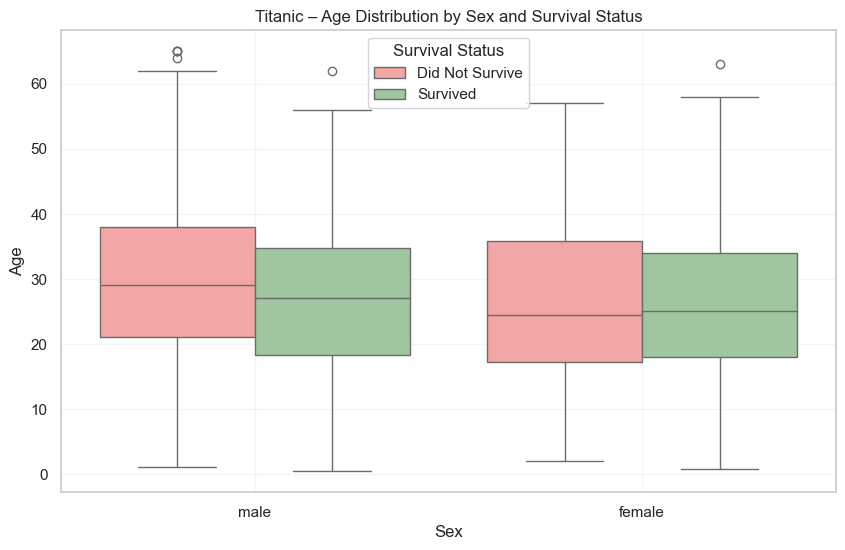

In [8]:
# Cell 8 – Main Plot: Age Distribution by Sex & Survival
palette_survived = {0: '#FF9999', 1: '#99CC99'}

plt.figure(figsize=(10, 6))
sns.boxplot(data=titanic_final, x='sex', y='age', hue='survived',
            palette=palette_survived)
plt.title('Titanic – Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Did Not Survive', 'Survived'], title='Survival Status')
plt.grid(alpha=0.2)
plt.show()

In [9]:
# Cell 9 – Supporting Statistics
print('Survival rate by Sex:')
print(titanic_final.groupby('sex')['survived'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'survivors', 'count': 'total', 'mean': 'survival_rate'}))

print('\nAge statistics by Sex and Survival:')
print(titanic_final.groupby(['sex', 'survived'])['age'].describe())

Survival rate by Sex:
        survivors  total  survival_rate
sex                                    
female        141    203       0.694581
male           78    407       0.191646

Age statistics by Sex and Survival:
                 count       mean        std   min    25%   50%    75%   max
sex    survived                                                             
female 0          62.0  25.419355  13.516594  2.00  17.25  24.5  35.75  57.0
       1         141.0  26.170213  13.689227  0.75  18.00  25.0  34.00  63.0
male   0         329.0  30.562310  12.943766  1.00  21.00  29.0  38.00  65.0
       1          78.0  25.894231  15.163666  0.42  18.25  27.0  34.75  62.0


## Observations

1. **Median Age** – Survivors (especially males) tend to be younger than non-survivors.
2. **Female Advantage** – Females show a narrower age spread and a much higher survival rate, reflecting the historical *"women and children first"* evacuation priority.
3. **Older Males** – The male non-survivor boxplot has a higher upper whisker, indicating older men were less likely to survive.
4. **Children** – Lower whisker values for both sexes suggest that younger children had a better chance of survival.
5. **Conclusion** – Sex and Age are strong predictors of survival; females and younger passengers had significantly better outcomes.
